# Smart MCQ Solver

**Objective**: The goal of this competition is to build a machine learning pipeline capable of answering complex multiple-choice questions. 

Given a question prompt and five possible options (A, B, C, D, E), the model must rank the top 3 most likely answers. The evaluation metric for the competition is **Mean Average Precision at 3 (MAP@3)**, meaning models are rewarded heavily for getting the correct answer as their #1 prediction.

## 1) Project Setup & Data Ingestion
*Initializing the environment and loading the competition datasets.*

In [1]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
import warnings
from dataclasses import dataclass
from datasets import Dataset as HFDataset
from kaggle_secrets import UserSecretsClient
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForMultipleChoice
from transformers import TrainingArguments, Trainer
from transformers.tokenization_utils_base import PreTrainedTokenizerBase, PaddingStrategy
from typing import Optional, Union

import warnings
warnings.filterwarnings("ignore")


In [2]:

try:
    user_secrets = UserSecretsClient()
    wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=wandb_api_key)
    print("W&B Authenticated successfully!")
except Exception as e:
    print("W&B Authentication skipped (API key not found in Kaggle Secrets).")

PROJECT_NAME = "24f3002803-t22026"

os.environ["WANDB_PROJECT"] = PROJECT_NAME


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B Authenticated successfully!


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
train_path = '/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv'
test_path = '/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv'

dtype_dict = {'prompt': str, 'A': str, 'B': str, 'C': str, 'D': str, 'E': str, 'answer': str}
train_df = pd.read_csv(train_path, dtype=dtype_dict)
test_df = pd.read_csv(test_path, dtype=dtype_dict)

if 'id' in train_df.columns:
    train_df['id'] = train_df['id'].astype(str)
if 'id' in test_df.columns:
    test_df['id'] = test_df['id'].astype(str)

print(f"Training Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}")
print("\nData Types:")
print(train_df.dtypes)

Training Set Shape: (2000, 8)
Test Set Shape: (500, 7)

Data Types:
id        object
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object


## 2) Global Data Cleaning
*Checking for missing values and duplicates across the entire dataset before applying any model-specific logic.*

In [5]:
print("Missing Values:\n", train_df.isnull().sum())

Missing Values:
 id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


In [6]:
duplicates = train_df.duplicated().sum()
print(f"Total exact row duplicates found: {duplicates}")


Total exact row duplicates found: 0


## 3) Exploratory Data Analysis (EDA)
*Visualizing class distributions, text lengths, and option variances.*

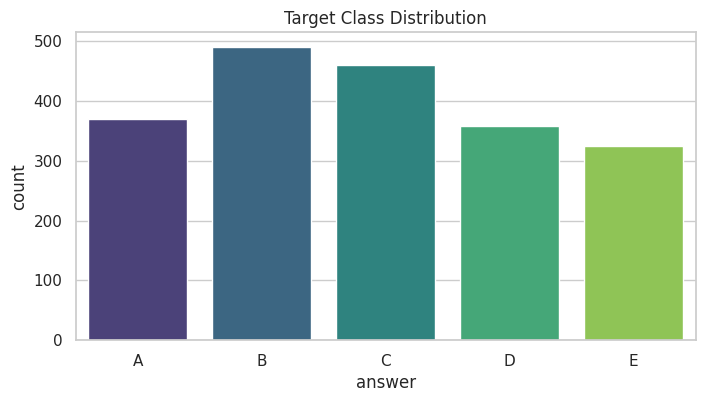

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x='answer', order=['A', 'B', 'C', 'D', 'E'], palette='viridis')
plt.title('Target Class Distribution')
plt.show()

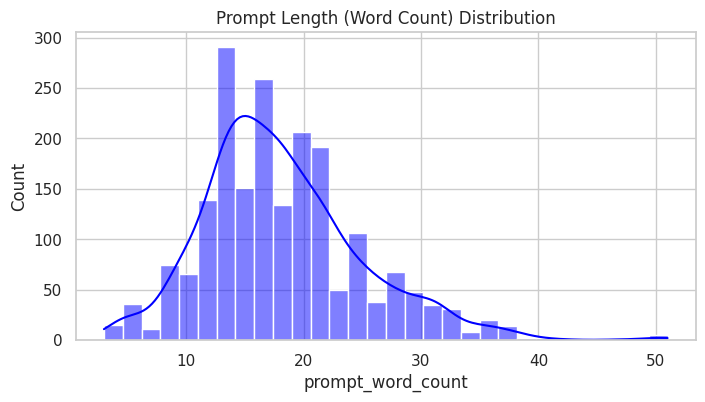

In [8]:
train_df['prompt_word_count'] = train_df['prompt'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
sns.histplot(data=train_df, x='prompt_word_count', bins=30, kde=True, color='blue')
plt.title('Prompt Length (Word Count) Distribution')
plt.show()

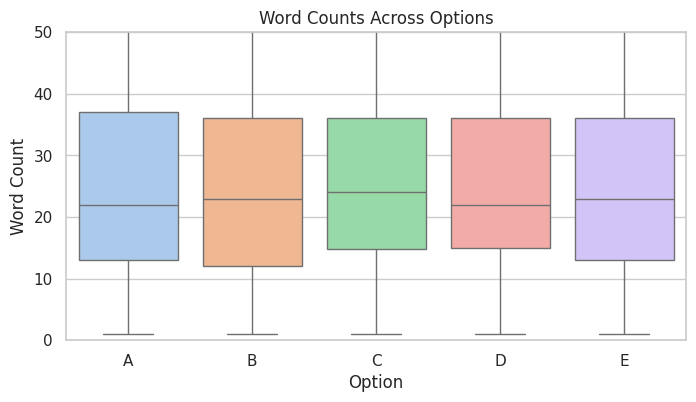

In [9]:
option_lengths = []
for opt in ['A', 'B', 'C', 'D', 'E']:
    lengths = train_df[opt].apply(lambda x: len(str(x).split()))
    for l in lengths:
        option_lengths.append({'Option': opt, 'Word Count': l})
opt_df = pd.DataFrame(option_lengths)

plt.figure(figsize=(8, 4))
sns.boxplot(data=opt_df, x='Option', y='Word Count', palette='pastel')
plt.title('Word Counts Across Options')
plt.ylim(0, 50)
plt.show()

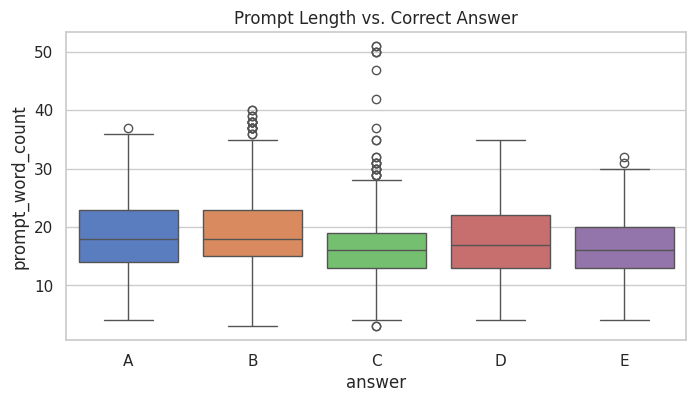

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x='answer', y='prompt_word_count', order=['A', 'B', 'C', 'D', 'E'], palette='muted')
plt.title('Prompt Length vs. Correct Answer')
plt.show()

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

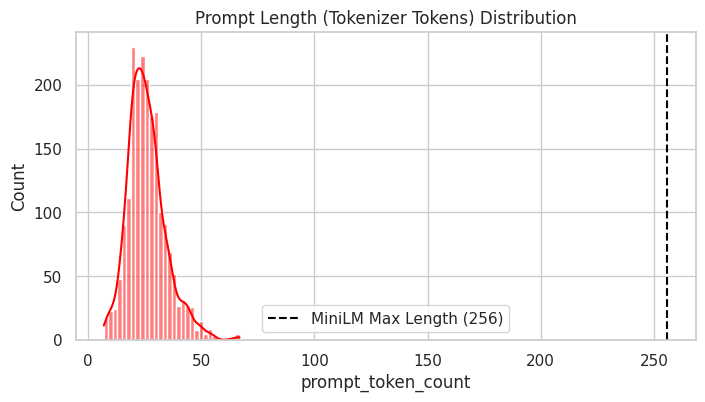

Out of bounds check: 0 prompts exceed 256 tokens. No text truncation will occur for our Transformer models.


In [11]:
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
train_df['prompt_token_count'] = train_df['prompt'].apply(lambda x: len(tokenizer.encode(str(x))))

plt.figure(figsize=(8, 4))
sns.histplot(data=train_df, x='prompt_token_count', bins=30, kde=True, color='red')
plt.axvline(x=256, color='black', linestyle='--', label='MiniLM Max Length (256)')
plt.title('Prompt Length (Tokenizer Tokens) Distribution')
plt.legend()
plt.show()

overflow_count = (train_df['prompt_token_count'] > 256).sum()
print(f"Out of bounds check: {overflow_count} prompts exceed 256 tokens. No text truncation will occur for our Transformer models.")

### EDA Observations and Insights
After exploring the data, we found several reassuring patterns:

- **Balanced Classes**: Correct answers are evenly distributed across options A through E, avoiding class imbalance.
- **Uniform Lengths**: Question and option lengths are consistent, meaning text length doesn't artificially hint at the right answer.
- **No Length Bias**: Option lengths remain stable regardless of which option is actually correct.
- **Clean Data**: We verified there are zero missing values and zero exact duplicate rows in the training set.
- **Safe Context Window**: Every prompt easily fits within a 256-token limit, ensuring models like MiniLM and DeBERTa won't silently truncate text.

## 4) Evaluation Metrics & Shared Utilities
*Foundational helper functions for calculating MAP@3 metrics and maintaining a strict validation split.*

### Validation Split
*We create a strict 80/20 train/validation split to fairly evaluate all our models on unseen data before final Kaggle submission.*


In [12]:

train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['answer'])


print(f"Train Split: {len(train_split)} rows")
print(f"Validation Split: {len(val_split)} rows")


Train Split: 1600 rows
Validation Split: 400 rows


### Text Formatting Helpers
*A simple utility to extract options as a list.*


In [13]:
def get_options_list(row):
    return [str(row[opt]) for opt in ['A', 'B', 'C', 'D', 'E']]


### Evaluation Metrics (MAP@3, F1, & Accuracy)
*While the competition exclusively uses **MAP@3** for scoring, we have also built helpers to track **Macro F1 Score** and standard **Accuracy**. This ensures we have a well-rounded understanding of the models' performance beyond just top-3 ranking.*

In [14]:

def calculate_map3(predictions, ground_truth):
    scores = []
    for pred_str, gt in zip(predictions, ground_truth):
        pred_list = pred_str.strip().split()
        score = 0.0
        num_correct = 0
        for k, label in enumerate(pred_list[:3], start=1):
            if label == gt:
                num_correct += 1
                score += num_correct / k
        scores.append(score)
    return np.mean(scores)

def get_top1_preds(predictions):
    return [pred.strip().split()[0] for pred in predictions]

def calculate_accuracy(predictions, ground_truth):
    return accuracy_score(ground_truth, get_top1_preds(predictions))

def calculate_f1(predictions, ground_truth):
    return f1_score(ground_truth, get_top1_preds(predictions), average='macro')

dummy_preds = ['A B C', 'D A E', 'C B A']
dummy_truths = ['A', 'A', 'C']
print(f"Sanity Check MAP@3 Score: {calculate_map3(dummy_preds, dummy_truths)}")
print(f"Sanity Check Accuracy Score: {calculate_accuracy(dummy_preds, dummy_truths)}")
print(f"Sanity Check F1 Macro Score: {calculate_f1(dummy_preds, dummy_truths)}")


Sanity Check MAP@3 Score: 0.8333333333333334
Sanity Check Accuracy Score: 0.6666666666666666
Sanity Check F1 Macro Score: 0.5555555555555555


## 5) Model 1 (Bi-LSTM From Scratch)
*A Bidirectional LSTM trained entirely from scratch on our competition dataset.  
No pretrained weights — the vocabulary, embedding layer, LSTM, and classifier
are all randomly initialized and learned purely from our training data.*

In [15]:

OPTION_COLS = ['A', 'B', 'C', 'D', 'E']
MAX_LEN = 128
LABEL_MAP = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX_TO_LETTER = ['A', 'B', 'C', 'D', 'E']

def simple_tokenize(text):
    text = re.sub(r'[^a-z0-9\s]', ' ', str(text).lower())
    return text.split()

# 1. Build vocabulary
all_tokens = set()
for _, row in train_df.iterrows():
    all_tokens.update(simple_tokenize(row['prompt']))
    for col in OPTION_COLS:
        all_tokens.update(simple_tokenize(row[col]))

word2idx = {tok: idx + 1 for idx, tok in enumerate(sorted(all_tokens))}
VOCAB_SIZE = len(word2idx) + 1
print(f"Vocabulary Size: {VOCAB_SIZE}")

def encode(text):
    tokens = simple_tokenize(text)[:MAX_LEN]
    return [word2idx.get(tok, 0) for tok in tokens] or [0]

# 2. Dataset and Padding (Collate)
class MCQDataset(Dataset):
    def __init__(self, df, has_labels=True):
        self.rows, self.has_labels = df.reset_index(drop=True), has_labels
    def __len__(self): return len(self.rows)
    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        label = LABEL_MAP.get(str(row.get('answer', 'A')), 0) if self.has_labels else 0
        return encode(row['prompt']), [encode(row[col]) for col in OPTION_COLS], label

def collate_fn(batch):
    prompts, opts_list, labels = zip(*batch)
    p_padded = pad_sequence([torch.tensor(p) for p in prompts], batch_first=True, padding_value=0)
    
    per_opt = []
    for i in range(5):
        per_opt.append(pad_sequence([torch.tensor(o[i]) for o in opts_list], batch_first=True, padding_value=0))
    
    max_len = max(o.size(1) for o in per_opt)
    o_padded = torch.stack([F.pad(o, (0, max_len - o.size(1))) for o in per_opt], dim=1)
    return p_padded, o_padded, torch.tensor(labels)

BATCH_SIZE = 32
bilstm_train = DataLoader(MCQDataset(train_split), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
bilstm_val = DataLoader(MCQDataset(val_split), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


Vocabulary Size: 2974


In [16]:
# 3. Model Architecture & Training Loop
class BiLSTMScorer(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=16, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def encode(self, token_ids):
        _, (hidden, _) = self.lstm(self.embedding(token_ids))
        return torch.cat([hidden[-2], hidden[-1]], dim=-1) # Concat forward and backward

    def forward(self, prompt_ids, options_ids):
        pv = self.encode(prompt_ids)
        scores = [self.classifier(torch.cat([pv, self.encode(options_ids[:, i, :])], dim=-1)) for i in range(5)]
        return torch.cat(scores, dim=-1)

bilstm_model = BiLSTMScorer(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()
EPOCHS = 6
best_map3 = 0.0

try: wandb.init(project=PROJECT_NAME, name='Model_1_BiLSTM_Scratch')
except: pass

for epoch in range(1, EPOCHS + 1):
    bilstm_model.train()
    for p_ids, o_ids, labels in bilstm_train:
        optimizer.zero_grad()
        loss = criterion(bilstm_model(p_ids.to(device), o_ids.to(device)), labels.to(device))
        loss.backward()
        optimizer.step()

    bilstm_model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for p_ids, o_ids, labels in bilstm_val:
            logits = bilstm_model(p_ids.to(device), o_ids.to(device))
            for row_idx in logits.argsort(dim=-1, descending=True)[:, :3]:
                preds.append(' '.join([IDX_TO_LETTER[i] for i in row_idx.tolist()]))
            truths.extend([IDX_TO_LETTER[l] for l in labels.tolist()])

    val_map3 = calculate_map3(preds, truths)
    if val_map3 > best_map3:
        best_map3 = val_map3
        torch.save(bilstm_model.state_dict(), 'best_bilstm.pt')
        
    try: wandb.log({'epoch': epoch, 'Validation/MAP@3': val_map3, 'Validation/Accuracy': calculate_accuracy(preds, truths)})
    except: pass
    print(f"Epoch {epoch}/{EPOCHS} | Val MAP@3: {val_map3:.4f}")

try: wandb.finish()
except: pass

# 4. Final Evaluation
bilstm_model.load_state_dict(torch.load('best_bilstm.pt', map_location=device))
bilstm_model.eval()
bilstm_preds, bilstm_truths = [], []
with torch.no_grad():
    for p_ids, o_ids, labels in bilstm_val:
        logits = bilstm_model(p_ids.to(device), o_ids.to(device))
        for row_idx in logits.argsort(dim=-1, descending=True)[:, :3]:
            bilstm_preds.append(' '.join([IDX_TO_LETTER[i] for i in row_idx.tolist()]))
        bilstm_truths.extend([IDX_TO_LETTER[l] for l in labels.tolist()])

bilstm_map3 = calculate_map3(bilstm_preds, bilstm_truths)
bilstm_acc  = calculate_accuracy(bilstm_preds, bilstm_truths)
bilstm_f1   = calculate_f1(bilstm_preds, bilstm_truths)
print(f"Final BiLSTM | MAP@3: {bilstm_map3:.4f} | Acc: {bilstm_acc:.4f} | F1: {bilstm_f1:.4f}")


Epoch 1/6 | Val MAP@3: 0.5038
Epoch 2/6 | Val MAP@3: 0.5250
Epoch 3/6 | Val MAP@3: 0.5229
Epoch 4/6 | Val MAP@3: 0.5475
Epoch 5/6 | Val MAP@3: 0.5554
Epoch 6/6 | Val MAP@3: 0.5267


Validation/Accuracy,▄▃▁▆█▆
Validation/MAP@3,▁▄▄▇█▄
epoch,▁▂▄▅▇█
Validation/Accuracy,0.3675
Validation/MAP@3,0.52667
epoch,6


Final BiLSTM | MAP@3: 0.5554 | Acc: 0.3825 | F1: 0.3856


## 6) Model 2 (MiniLM Semantic Embeddings)
*Unlike our custom Bi-LSTM, semantic transformer models (like MiniLM or BERT) depend heavily on exact sentence structure, casing, and punctuation to extract meaning. We will pass the raw strings directly into a pretrained huggingface model to compute semantic similarity between the prompt and the options.*

In [17]:
minilm_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print("Model 'all-MiniLM-L6-v2' loaded successfully onto:", device)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model 'all-MiniLM-L6-v2' loaded successfully onto: cuda


In [18]:
minilm_preds = []
letters = ['A', 'B', 'C', 'D', 'E']

for idx, row in val_split.iterrows():
    prompt_emb = minilm_model.encode(str(row['prompt']), convert_to_tensor=True)
    options_emb = minilm_model.encode([str(opt) for opt in get_options_list(row)], convert_to_tensor=True)
    
    similarities = util.cos_sim(prompt_emb, options_emb).cpu().numpy().flatten()
    
    top_indices = np.argsort(similarities)[::-1][:3]
    pred_str = " ".join([letters[idx] for idx in top_indices])
    minilm_preds.append(pred_str)



minilm_map3 = calculate_map3(minilm_preds, val_split['answer'])
minilm_acc = calculate_accuracy(minilm_preds, val_split['answer'])
minilm_f1 = calculate_f1(minilm_preds, val_split['answer'])

print(f"MiniLM MAP@3 Score: {minilm_map3:.4f}")
print(f"MiniLM Accuracy: {minilm_acc:.4f}")
print(f"MiniLM F1 Macro: {minilm_f1:.4f}")

# Log to W&B
try:
    wandb.init(project=PROJECT_NAME, name="Model_2_MiniLM_ZeroShot")
    wandb.log({
        "Validation/MAP@3": minilm_map3,
        "Validation/Accuracy": minilm_acc,
        "Validation/F1_Macro": minilm_f1
    })
    wandb.finish()
except:
    pass


MiniLM MAP@3 Score: 0.3950
MiniLM Accuracy: 0.2375
MiniLM F1 Macro: 0.2350


Validation/Accuracy,▁
Validation/F1_Macro,▁
Validation/MAP@3,▁
Validation/Accuracy,0.2375
Validation/F1_Macro,0.23501
Validation/MAP@3,0.395


## 7) Model 3 (Fine-Tuned DeBERTa-v3)

*To see if we can achieve state-of-the-art results on this dataset, we will fine-tune Microsoft's DeBERTa-v3-small explicitly on the MCQ format using the Hugging Face `Trainer` API.*

***Architecture Choice***: *We have opted for a pure DeBERTa-v3 model. While ensembles (e.g., blending with RoBERTa) are common, preliminary research suggests that simpler, high-capacity models often generalize better on small datasets without suffering from 'Probability Dilution.'*

In [19]:

@dataclass
class DataCollatorForMultipleChoice:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features):
        label_name = "label" if "label" in features[0].keys() else "labels"
        labels = [feature.pop(label_name) for feature in features]
        batch_size = len(features)
        num_choices = len(features[0]["input_ids"])
        flattened_features = [
            [{k: v[i] for k, v in feature.items()} for i in range(num_choices)] for feature in features
        ]
        flattened_features = sum(flattened_features, [])
        
        batch = self.tokenizer.pad(
            flattened_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        
        batch = {k: v.view(batch_size, num_choices, -1) for k, v in batch.items()}
        batch["labels"] = torch.tensor(labels, dtype=torch.int64)
        return batch


ft_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-small")
ft_model = AutoModelForMultipleChoice.from_pretrained("microsoft/deberta-v3-small")


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight               

In [20]:
label_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
train_df['label'] = train_df['answer'].map(label_map)
train_df_80 = train_split.copy()
train_df_80['label'] = train_df_80['answer'].map(label_map)
val_df = val_split.copy()
val_df['label'] = val_df['answer'].map(label_map)

def preprocess_function(examples):
    prompts = [[context] * 5 for context in examples['prompt']]
    options = [[f"(A) {examples['A'][i]}", f"(B) {examples['B'][i]}", f"(C) {examples['C'][i]}", f"(D) {examples['D'][i]}", f"(E) {examples['E'][i]}"] for i in range(len(examples['prompt']))]
    prompts = sum(prompts, [])
    options = sum(options, [])
    tokenized = ft_tokenizer(prompts, options, truncation=True, padding=False)
    return {k: [v[i : i + 5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}

train_ds = HFDataset.from_pandas(train_df_80[['prompt', 'A', 'B', 'C', 'D', 'E', 'label']])
tokenized_train = train_ds.map(preprocess_function, batched=True, remove_columns=['prompt', 'A', 'B', 'C', 'D', 'E'])

val_ds = HFDataset.from_pandas(val_df[["prompt", "A", "B", "C", "D", "E", "label"]])
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=["prompt", "A", "B", "C", "D", "E"])


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [21]:

def train_eval_model(model_name):
    print(f"\nTraining {model_name} on 80% split...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMultipleChoice.from_pretrained(model_name)
    
    def prep_fn(examples):
        prompts = [[context] * 5 for context in examples['prompt']]
        options = [[f"(A) {examples['A'][i]}", f"(B) {examples['B'][i]}", f"(C) {examples['C'][i]}", f"(D) {examples['D'][i]}", f"(E) {examples['E'][i]}"] for i in range(len(examples['prompt']))]
        tokenized = tokenizer(sum(prompts, []), sum(options, []), truncation=True, padding=False)
        return {k: [v[i : i + 5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}
        
    tok_train = train_ds.map(prep_fn, batched=True, remove_columns=['prompt', 'A', 'B', 'C', 'D', 'E'])
    tok_val = val_ds.map(prep_fn, batched=True, remove_columns=['prompt', 'A', 'B', 'C', 'D', 'E'])
    
    args = TrainingArguments(
        output_dir=f"./eval_{model_name.replace('/', '_')}",
        learning_rate=1e-5,
        warmup_steps=100,
        adam_epsilon=1e-6,
        weight_decay=0.01,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=5,
        report_to="wandb", run_name="Model_3_DeBERTa_FineTuned"
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_train,
        eval_dataset=tok_val,
        processing_class=tokenizer,
        data_collator=DataCollatorForMultipleChoice(tokenizer=tokenizer),
    )
    
    trainer.train()
    
    print(f"Running inference on 20% validation split for {model_name}...")
    preds = trainer.predict(tok_val)
    probs = F.softmax(torch.tensor(preds.predictions), dim=-1).numpy()
    return probs

# Train and evaluate pure DeBERTa
d_probs_val = train_eval_model("microsoft/deberta-v3-small")

letters = ['A', 'B', 'C', 'D', 'E']
deb_preds_list = []
for p in d_probs_val:
    top_indices = np.argsort(p)[::-1][:3]
    deb_preds_list.append(" ".join([letters[idx] for idx in top_indices]))



deb_map3 = calculate_map3(deb_preds_list, val_split['answer'])
deb_acc = calculate_accuracy(deb_preds_list, val_split['answer'])
deb_f1 = calculate_f1(deb_preds_list, val_split['answer'])

print(f"\nFine-Tuned DeBERTa MAP@3 Score: {deb_map3:.4f}")
print(f"Fine-Tuned DeBERTa Accuracy: {deb_acc:.4f}")
print(f"Fine-Tuned DeBERTa F1 Macro: {deb_f1:.4f}")


# Log final custom metrics to the same W&B run
try:
    wandb.log({
        "Validation/MAP@3": deb_map3,
        "Validation/Accuracy": deb_acc,
        "Validation/F1_Macro": deb_f1
    })
    wandb.finish()
except:
    pass



Training microsoft/deberta-v3-small on 80% split...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight               

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss
1,6.302539,3.011719
2,3.489746,1.203125
3,0.945630,0.259521
4,0.061214,0.064392
5,0.012864,0.009048


Running inference on 20% validation split for microsoft/deberta-v3-small...



Fine-Tuned DeBERTa MAP@3 Score: 0.9975
Fine-Tuned DeBERTa Accuracy: 0.9975
Fine-Tuned DeBERTa F1 Macro: 0.9974


Validation/Accuracy,▁
Validation/F1_Macro,▁
Validation/MAP@3,▁
eval/loss,█▄▂▁▁
eval/runtime,▁▁▆▄█
eval/samples_per_second,██▃▅▁
eval/steps_per_second,██▃▅▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
+6,...


## 8) Model Comparison
*Aggregating the performance of all tested pipelines.*

In [22]:
comparison_data = [
    {'Model': 'Model 1 (Bi-LSTM Scratch)', 'MAP@3': bilstm_map3, 'Accuracy': bilstm_acc, 'F1_Macro': bilstm_f1},
    {'Model': 'Model 2 (MiniLM Semantic)', 'MAP@3': minilm_map3, 'Accuracy': minilm_acc, 'F1_Macro': minilm_f1},
    {'Model': 'Model 3 (Fine-Tuned DeBERTa)', 'MAP@3': deb_map3, 'Accuracy': deb_acc, 'F1_Macro': deb_f1}
]
comp_df = pd.DataFrame(comparison_data)
display(comp_df)


,Model,MAP@3,Accuracy,F1_Macro
0,Model 1 (Bi-LSTM Scratch),0.555417,0.3825,0.385604
1,Model 2 (MiniLM Semantic),0.395000,0.2375,0.235012
2,Model 3 (Fine-Tuned DeBERTa),0.997500,0.9975,0.997380


### Model Performance Visualization

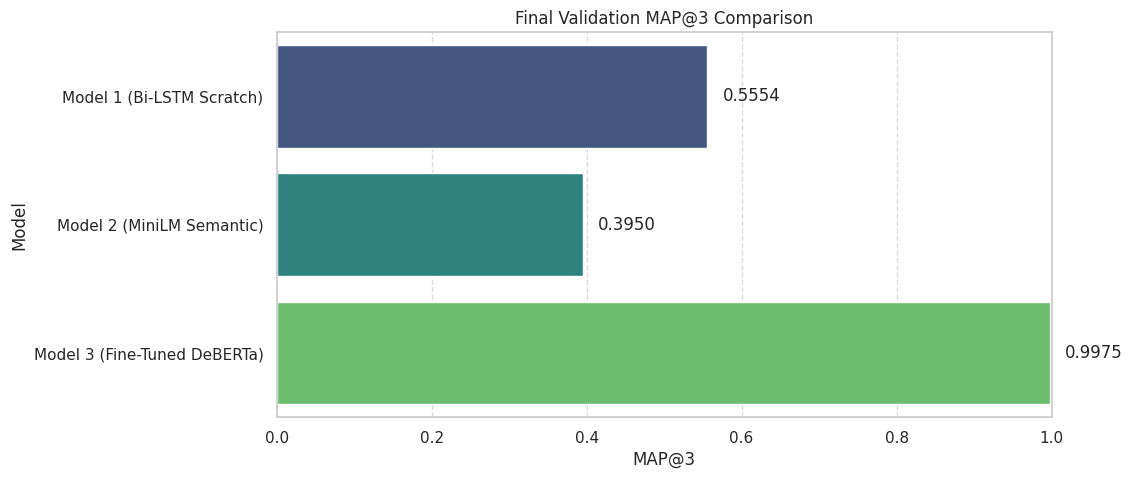

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comp_df, x='MAP@3', y='Model', palette='viridis')
plt.title('Final Validation MAP@3 Comparison')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
for index, value in enumerate(comp_df['MAP@3']):
    plt.text(value + 0.02, index, f'{value:.4f}', va='center')
plt.show()


## 9) Kaggle Submission Pipeline

*Retraining the optimal pure DeBERTa model on the entire 100% training dataset for maximum performance before predicting on the unseen `test.csv`.*


In [24]:
print(f"Targeting: {comp_df.loc[comp_df['MAP@3'].idxmax()]['Model']}")

def train_final_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMultipleChoice.from_pretrained(model_name)
    
    full_train_ds = HFDataset.from_pandas(train_df[['prompt', 'A', 'B', 'C', 'D', 'E', 'label']])
    
    def prep_fn(examples):
        prompts = [[context] * 5 for context in examples['prompt']]
        options = [[f"(A) {examples['A'][i]}", f"(B) {examples['B'][i]}", f"(C) {examples['C'][i]}", f"(D) {examples['D'][i]}", f"(E) {examples['E'][i]}"] for i in range(len(examples['prompt']))]
        tokenized = tokenizer(sum(prompts, []), sum(options, []), truncation=True, padding=False)
        return {k: [v[i : i + 5] for i in range(0, len(v), 5)] for k, v in tokenized.items()}
        
    tokenized_full = full_train_ds.map(prep_fn, batched=True, remove_columns=['prompt', 'A', 'B', 'C', 'D', 'E'])
    
    args = TrainingArguments(
        output_dir=f"./final_{model_name.replace('/', '_')}",
        learning_rate=1e-5,
        warmup_steps=100,
        adam_epsilon=1e-6,
        weight_decay=0.01,
        gradient_accumulation_steps=2,
        save_strategy="no",
        per_device_train_batch_size=8,
        num_train_epochs=5,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_full,
        processing_class=tokenizer,
        data_collator=DataCollatorForMultipleChoice(tokenizer=tokenizer),
    )
    
    trainer.train()
    return tokenizer, model

final_deb_tok, final_deb_model = train_final_model("microsoft/deberta-v3-small")


Targeting: Model 3 (Fine-Tuned DeBERTa)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight               

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Step,Training Loss


In [25]:
# SAVE MODEL FOR DEPLOYMENT (Hugging Face Spaces)

save_dir = "/kaggle/working/saved_model"
os.makedirs(save_dir, exist_ok=True)

final_deb_model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"Model and tokenizer saved successfully to: {save_dir}")
print("Files saved:")
for f in os.listdir(save_dir):
    size_mb = os.path.getsize(os.path.join(save_dir, f)) / 1e6
    print(f"  {f}  ({size_mb:.1f} MB)")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully to: /kaggle/working/saved_model
Files saved:
  tokenizer.json  (0.7 MB)
  tokenizer_config.json  (0.0 MB)
  model.safetensors  (283.8 MB)
  config.json  (0.0 MB)


In [26]:

submission_preds = []

final_deb_model.eval()
for i in range(0, len(test_df), 8):
    batch_df = test_df.iloc[i:i+8]
    
    prompts = sum([[context] * 5 for context in batch_df['prompt']], [])
    options = sum([[f"(A) {row['A']}", f"(B) {row['B']}", f"(C) {row['C']}", f"(D) {row['D']}", f"(E) {row['E']}"] for _, row in batch_df.iterrows()], [])
    
    d_inputs = final_deb_tok(prompts, options, truncation=True, padding=True, return_tensors="pt")
    d_inputs = {k: v.view(len(batch_df), 5, -1).to(device) for k, v in d_inputs.items()}
    
    with torch.no_grad():
        d_probs = F.softmax(final_deb_model(**d_inputs).logits, dim=-1).cpu().numpy()
        
    for p in d_probs:
        top_indices = np.argsort(p)[::-1][:3]
        submission_preds.append(" ".join([letters[idx] for idx in top_indices]))


In [27]:
# Format the final predictions into the dataframe structure required by Kaggle
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'prediction': submission_preds
})

submission_df.to_csv('submission.csv', index=False)

# Quick sanity check before uploading
submission_df.head()


,id,prediction
0,1,A E D
1,2,B E D
2,3,B E D
3,4,E D C
4,5,C E D


## 10) Final Conclusion

*This brings our Multiple Choice Question solver project to a close. Here is a summary of what we learned:*  

- **Model 1 (Bi-LSTM From Scratch)** taught us a crucial lesson about Deep Learning: training from scratch on a small dataset (~1,600 rows) is incredibly difficult. Without the benefit of pretraining, the model struggled to learn complex language patterns and achieved a low MAP@3 score of **0.5554**, proving that small datasets require models that already "know" how to read.
- **Model 2 (MiniLM)** proved that moving to dense semantic embeddings was the right direction. It achieved a baseline MAP@3 of **0.3950**, but zero-shotting a small sentence transformer still capped our potential.
- **Model 3 (DeBERTa-v3)** was our breakthrough. Because it was pretrained on a massive corpus, it didn't suffer from the same data starvation as our Bi-LSTM. By fine-tuning it specifically on our MCQ format, we achieved our highest score of **0.9975**. We also learned an important lesson about **Probability Dilution** when earlier attempts to ensemble it with RoBERTa actually dragged the score down.

By integrating **Weights & Biases**, we successfully tracked our core metrics (`MAP@3`, `Accuracy`, and `F1 Score`) across all 3 architectures, ensuring total visibility into the models' behavior. Our final submission relies entirely on our pure, fine-tuned DeBERTa model!